# Portfolio Risk Estimation and Backtesting with Python

## Introduction

Financial institutions routinely quantify the risk of their portfolios to support investment decisions, regulatory compliance, and capital allocation. Among the most widely used risk measures are **Value-at-Risk (VaR)** and **Expected Shortfall (ES)**, which summarize the potential losses of a portfolio under adverse market conditions.

Value-at-Risk estimates the maximum expected loss over a given time horizon at a specified confidence level. For example, a one-day 95% VaR of \$10,000 indicates that, under normal market conditions, losses are expected to exceed \$10,000 on only 5% of trading days. While VaR is widely adopted due to its simplicity and interpretability, it provides no information about the magnitude of losses **beyond this threshold**.

Expected Shortfall addresses this limitation by measuring the **average loss conditional on losses exceeding the VaR threshold**. Because it captures the severity of tail events, ES is considered a more informative risk measure and has become the regulatory standard under the Basel III market risk framework.

This notebook implements and compares three widely used methodologies for estimating portfolio risk:


*   **Historical Simulation**, a non-parametric approach that estimates risk directly from historical observations without assuming any probability distribution.
*   **Parametric (Variance-Covariance) Method**, which assumes portfolio returns follow a normal distribution and derives analytical expressions for VaR and ES.
*   **Monte Carlo Simulation**, which generates thousands of possible future market scenarios based on the estimated statistical properties of historical returns, providing a flexible framework for risk estimation.


Since estimating risk is only part of the modeling process, the notebook also performs **rolling-window backtesting** to evaluate the predictive performance of each methodology. The estimated VaR and ES are compared against realized portfolio losses, exception rates are analyzed, and the Kupiec Proportion of Failures Test is applied to assess whether the observed number of VaR exceedances is *statistically consistent* with the chosen confidence level.

The primary objective of this project is to build a complete portfolio risk analysis workflow in Python, covering data preparation, implementation of multiple risk estimation techniques, model comparison, backtesting, statistical validation, and visualization of results. Beyond computing risk measures, the project emphasizes the importance of evaluating model performance and interpreting risk estimates in a practical financial context.

## Data collection

This project uses historical daily adjusted closing prices downloaded from Yahoo Finance through the `yfinance` library. The portfolio consists of several publicly traded assets combined using **fixed portfolio weights**. These historical prices provide the basis for estimating returns, portfolio value, and subsequent risk measures.

After downloading the data, we observe that there are no missing observations so we ensure a consistent time series across all assets. Daily log returns are then computed, as they are additive over time and commonly used in quantitative finance.


In [2]:
import yfinance as yf

tickers = ["SPY", "QQQ", "GLD", "TLT", "EEM"]

prices = yf.download(tickers, start = "2018-01-01", auto_adjust=True)["Close"]

prices.head()

[*********************100%***********************]  5 of 5 completed


Ticker,EEM,GLD,QQQ,SPY,TLT
Date,,,,,
2018-01-02,39.776550,125.150002,150.057236,235.954330,97.947906
2018-01-03,40.157669,124.820000,151.515366,237.446747,98.416199
2018-01-04,40.356514,125.459999,151.780396,238.447525,98.400543
2018-01-05,40.704479,125.330002,153.304688,240.036621,98.119621
2018-01-08,40.704479,125.309998,153.901184,240.475525,98.057159


## Exploratory Data Analisis

Before estimating portfolio risk, it is important to understand the basic characteristics of the data. This section examines the historical behavior of asset prices and returns, providing insight into their volatility and overall dynamics.

The portfolio value is constructed using fixed asset weights, allowing all subsequent risk measures to be evaluated from the perspective of the entire portfolio rather than individual securities.

In [3]:
prices.info()

prices.describe()

prices.isna().sum()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2158 entries, 2018-01-02 to 2026-08-04
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   EEM     2158 non-null   float64
 1   GLD     2158 non-null   float64
 2   QQQ     2158 non-null   float64
 3   SPY     2158 non-null   float64
 4   TLT     2158 non-null   float64
dtypes: float64(5)
memory usage: 101.2 KB


,0
Ticker,
EEM,0
GLD,0
QQQ,0
SPY,0
TLT,0


In [23]:
import numpy as np

returns = np.log(prices / prices.shift(1))
returns.dropna(inplace=True) # We drop the first row of the dataset, since returns use shifted prices
returns.head()

Ticker,EEM,GLD,QQQ,SPY,TLT
Date,,,,,
2018-01-03,0.009536,-0.002640,0.009670,0.006305,0.004770
2018-01-04,0.004939,0.005114,0.001748,0.004206,-0.000159
2018-01-05,0.008585,-0.001037,0.009993,0.006642,-0.002859
2018-01-08,0.000000,-0.000160,0.003883,0.001827,-0.000637
2018-01-09,-0.001630,-0.004639,0.000061,0.002261,-0.013463


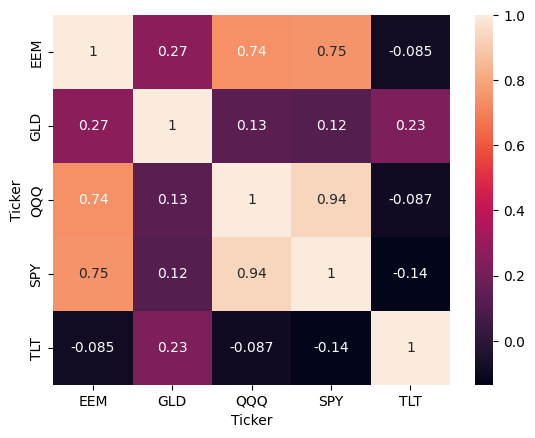

In [29]:
# Correlation matrix

returns.describe()
corr = returns.corr()

import seaborn as sns

sns.heatmap(corr, annot=True)
plt.show()

<Axes: xlabel='Ticker'>

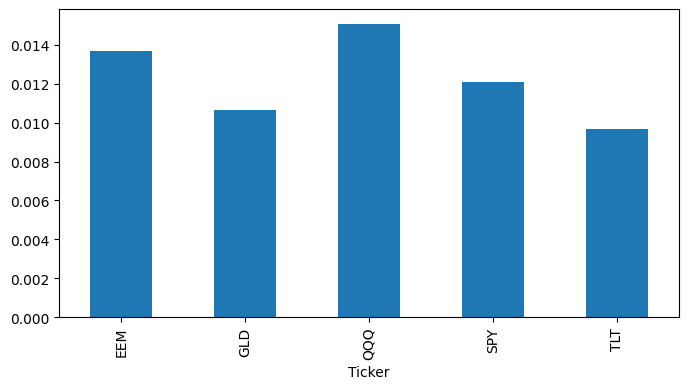

In [27]:
# Volatily of each asset
returns.std().plot.bar(figsize=(8,4))

array([[<Axes: title={'center': 'EEM'}>, <Axes: title={'center': 'GLD'}>],
       [<Axes: title={'center': 'QQQ'}>, <Axes: title={'center': 'SPY'}>],
       [<Axes: title={'center': 'TLT'}>, <Axes: >]], dtype=object)

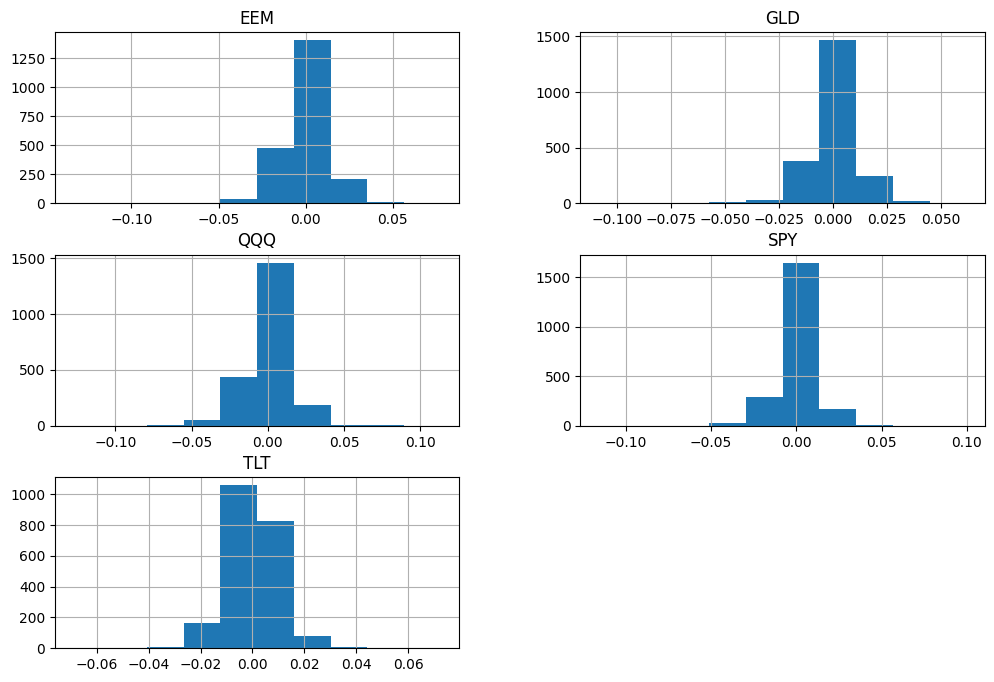

In [28]:
# Returns histogram of each asset
returns.hist(figsize=(12,8))

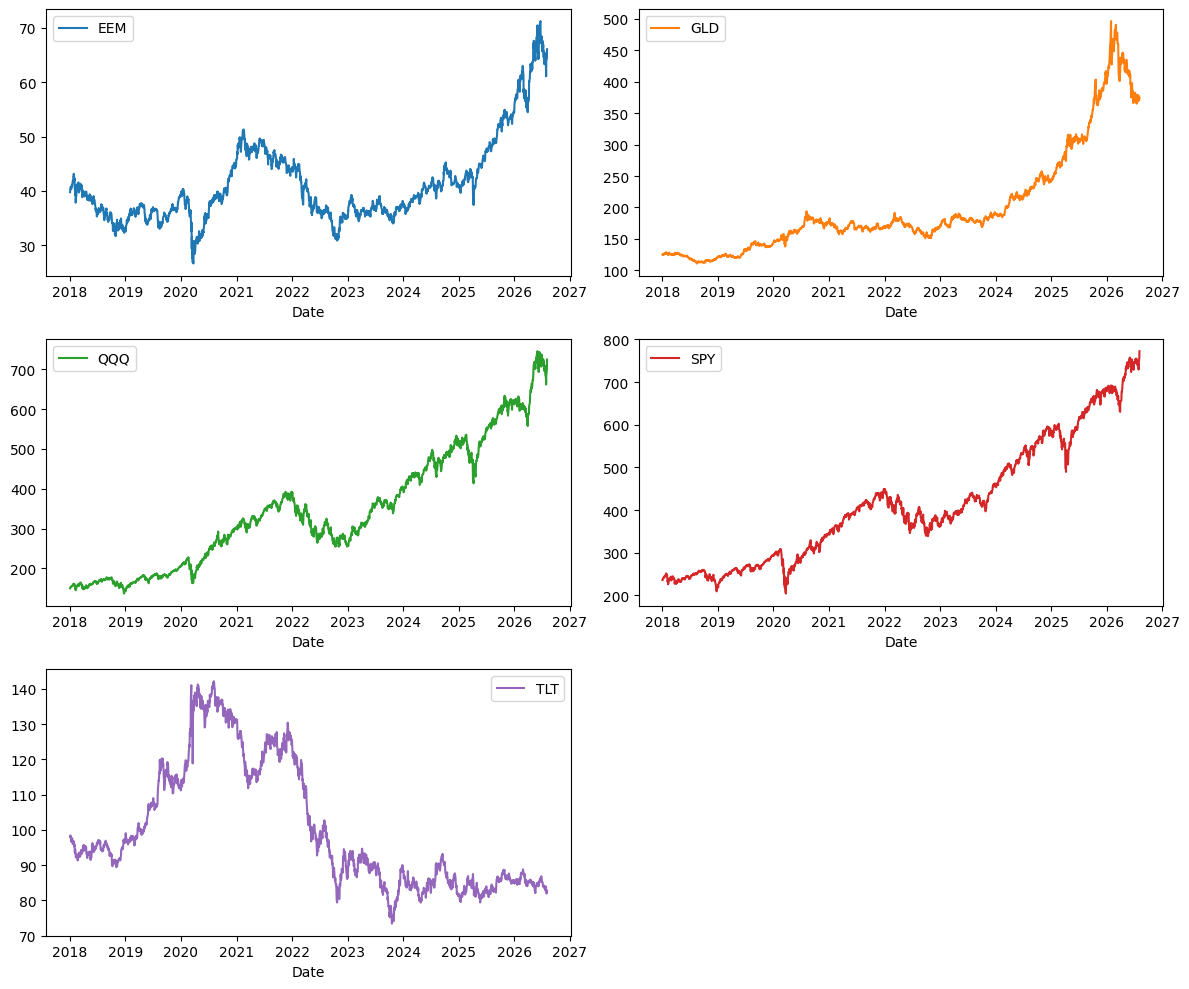

In [5]:
# Prices plot of each asset
import matplotlib.pyplot as plt

prices.plot(subplots=True,
             figsize=(12,10),
             layout=(-1,2),
             sharex=False,
             legend=True)
plt.tight_layout()

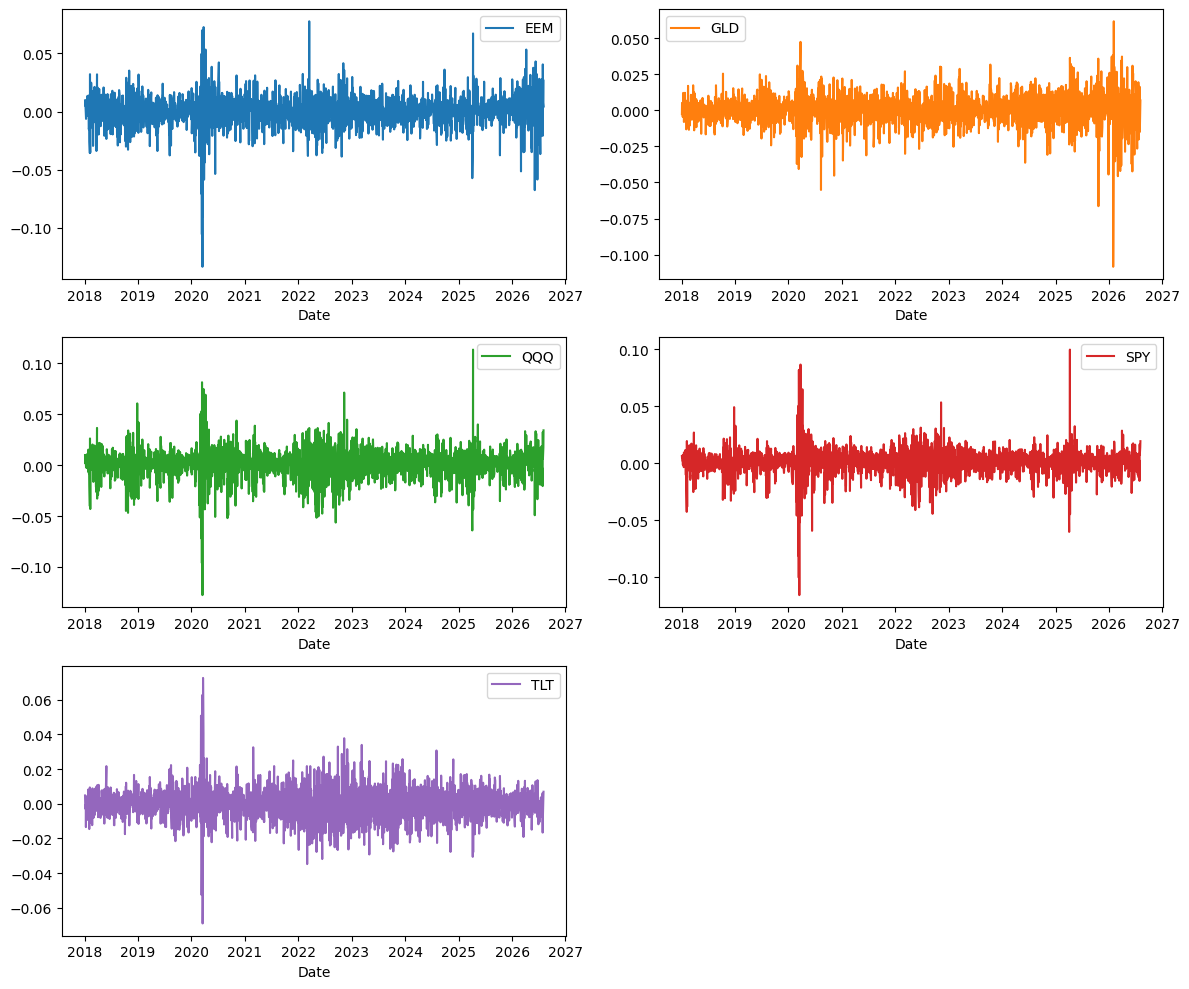

In [6]:
# Returns plot of each asset
import matplotlib.pyplot as plt

returns.plot(subplots=True,
             figsize=(12,10),
             layout=(-1,2),
             sharex=False,
             legend=True)
plt.tight_layout()

The return series exhibit the typical characteristics of financial data, including periods of relatively low volatility interrupted by episodes of heightened market turbulence. A particularly pronounced increase in volatility can be observed during the early months of the COVID-19 pandemic in 2020, reflecting the severe market uncertainty experienced during that period. These observations motivate the use of quantitative risk measures such as Value-at-Risk (VaR) and Expected Shortfall (ES), which summarize the potential magnitude of portfolio losses under adverse market conditions.

## Portfolio Construction

In [7]:
# Weights for the portfolio
weights = np.array([
    0.30,
    0.25,
    0.15,
    0.20,
    0.10
])

# Portfolio returns through time
portfolio_returns = returns @ weights

display(portfolio_returns.head())

# Portfolio value through time
portfolio_value = prices @ weights
display(portfolio_value.head())

,0
Date,
2018-01-03,0.005389
2018-01-04,0.003848
2018-01-05,0.004858
2018-01-08,0.000844
2018-01-09,-0.002534


,0
Date,
2018-01-02,122.714708
2018-01-03,123.310575
2018-01-04,123.768573
2018-01-05,124.358834
2018-01-08,124.524842


## Historical Value-at-Risk and Expected Shortfall

Historical Simulation is one of the simplest and most intuitive approaches for estimating market risk. Instead of assuming a probability distribution, it directly uses the empirical distribution of historical portfolio returns.

The Value-at-Risk is obtained as the empirical quantile of the historical loss distribution, while the Expected Shortfall corresponds to the average loss beyond the VaR threshold. Because no distributional assumptions are imposed, this methodology naturally captures skewness and heavy tails present in historical data.

In [8]:
def historical_var(portfolio_value, portfolio_returns, alpha=0.05):
    """
    Historical Value at Risk.

    Parameters
    ----------
    portfolio_value : array-like
        Historical portfolio value.
    alpha : float
        Tail probability (0.05 = 95% VaR).

    Returns
    -------
    float
        Positive VaR.
    """
    current_value = portfolio_value.iloc[-1]

    losses = -current_value * portfolio_returns

    var = np.quantile(losses, 1-alpha)

    return var



def historical_es(portfolio_value, portfolio_returns, alpha=0.05):
    """
    Historical Expected Shortfall.

    Parameters
    ----------
    portfolio_value : array-like
        Historical portfolio value.
    portfolio_returns : array-like
        Historical portfolio returns.
    alpha : float
        Tail probability (0.05 = 95% ES).

    Returns
    -------
    float
        Expected Shortfall in currency units.
    """

    current_value = portfolio_value.iloc[-1]

    losses = -current_value * portfolio_returns

    var = np.quantile(losses, 1 - alpha)

    es = losses[losses >= var].mean()

    return es


import pandas as pd

def risk_summary(portfolio_value, portfolio_returns, alphas=[0.05, 0.01]):
    """
    Summary table with Historical VaR and ES.

    Parameters
    ----------
    portfolio_value : pandas.Series
        Historical portfolio values.
    portfolio_returns : pandas.Series
        Historical portfolio returns.
    alphas : list
        Tail probabilities.

    Returns
    -------
    pandas.DataFrame
    """

    summary = []

    for alpha in alphas:

        summary.append({
            "Confidence": f"{int((1-alpha)*100)}%",
            "VaR": historical_var(portfolio_value, portfolio_returns, alpha),
            "ES": historical_es(portfolio_value, portfolio_returns, alpha)
        })

    return pd.DataFrame(summary)

In [9]:
risk_summary(portfolio_value, portfolio_returns, alphas = [0.05, 0.01])

,Confidence,VaR,ES
0,95%,5.414581,8.282024
1,99%,9.315696,14.153431


The Historical Simulation approach provides a purely data-driven estimate of portfolio risk. Its main advantage is the absence of parametric assumptions; however, its accuracy depends heavily on the representativeness of the historical sample and may not adequately capture future market conditions that differ from the past.

## Parametric Value-at-Risk and Expected Shortfall

The Parametric (Variance-Covariance) approach assumes that portfolio returns follow a normal distribution. Under this assumption, VaR and Expected Shortfall can be computed analytically using the estimated mean and standard deviation of portfolio returns.

Although this method is computationally efficient, its accuracy depends on the validity of the normality assumption, which **may underestimate** extreme market events.

In [10]:
# Var y ES paramétricos

from scipy.stats import norm

def parametric_var(portfolio_value, portfolio_returns, alpha=0.05):

    current_value = portfolio_value.iloc[-1]

    mu = portfolio_returns.mean()

    sigma = np.std(portfolio_returns, ddof=1)

    z = norm.ppf(alpha)

    var = -(mu + sigma*z)*current_value

    return var

def parametric_es(portfolio_value, portfolio_returns, alpha=0.05):
    """
    Computes the Parametric Expected Shortfall (ES) assuming
    portfolio returns follow a normal distribution.

    Parameters
    ----------
    portfolio_returns : array-like
        Historical portfolio returns.

    confidence : float, default=0.95
        Confidence level.

    Returns
    -------
    float
        Expected Shortfall expressed as a positive loss.
    """

    mu = np.mean(portfolio_returns)
    sigma = np.std(portfolio_returns, ddof=1)
    current_value = portfolio_value.iloc[-1]
    z = norm.ppf(1-alpha)

    es = current_value*(-mu + sigma * norm.pdf(z) / alpha)

    return es

def risk_summary(portfolio_value, portfolio_returns, alphas=[0.05, 0.01]):
    """
    Summary table with Historical VaR and ES.

    Parameters
    ----------
    portfolio_value : pandas.Series
        Historical portfolio values.
    portfolio_returns : pandas.Series
        Historical portfolio returns.
    alphas : list
        Tail probabilities.

    Returns
    -------
    pandas.DataFrame
    """

    summary = []

    for alpha in alphas:

        summary.append({
            "Confidence": f"{int((1-alpha)*100)}%",
            "VaR Hist": historical_var(portfolio_value, portfolio_returns, alpha),
            "VaR Param": parametric_var(portfolio_value, portfolio_returns, alpha),
            "ES Hist": historical_es(portfolio_value, portfolio_returns, alpha),
            "ES Param": parametric_es(portfolio_value, portfolio_returns, alpha)
        })

    return pd.DataFrame(summary)

In [11]:
risk_summary(portfolio_value, portfolio_returns, alphas = [0.05, 0.01])

,Confidence,VaR Hist,VaR Param,ES Hist,ES Param
0,95%,5.414581,5.617214,8.282024,7.084206
1,99%,9.315696,8.009759,14.153431,9.199429


Compared with Historical Simulation, the Parametric approach produces analytical estimates that are fast to compute and widely used in practice. Nevertheless, departures from normality may affect the reliability of the resulting risk measures.

## Monte Carlo Value-at-Risk and Expected Shortfall

Monte Carlo Simulation estimates portfolio risk by generating a large number of possible future return scenarios. The simulations are produced from the estimated mean vector and covariance matrix of historical asset returns under a multivariate normal model.

Unlike Historical Simulation, Monte Carlo is capable of generating scenarios that were not directly observed in the historical sample, providing a flexible framework for portfolio risk estimation.

In [12]:
def monte_carlo_returns(returns, n_simulations=10_000):
    """
    Generates Monte Carlo simulations of asset returns assuming
    a multivariate normal distribution.

    Parameters
    ----------
    returns : DataFrame
        Historical asset returns.

    n_simulations : int
        Number of simulated scenarios.

    Returns
    -------
    ndarray
        Simulated asset returns.
    """

    mu = returns.mean().values
    cov = returns.cov().values

    simulations = np.random.multivariate_normal(
        mean=mu,
        cov=cov,
        size=n_simulations
    )

    return simulations

def monte_carlo_portfolio_returns(returns, weights, n_simulations=10000):
    """
    Simulates portfolio returns using Monte Carlo.
    """

    simulated_returns = monte_carlo_returns(
        returns,
        n_simulations
    )

    portfolio_returns = simulated_returns @ weights

    return portfolio_returns

def monte_carlo_var(prices, returns, weights, alpha=0.05, n_simulations=10000):
    """
    Computes the Monte Carlo Value-at-Risk (VaR) building
    portfolio returns through a Monte Carlo method.
    """
    portfolio_returns = monte_carlo_portfolio_returns(
        returns,
        weights,
        n_simulations
    )

    current_value = prices.iloc[-1] @ weights

    losses = -portfolio_returns * current_value # Check all possible scenarios

    var = np.percentile(
        losses,
        (1-alpha) * 100
    )

    return var

def monte_carlo_es(prices, returns, weights, alpha=0.05, n_simulations=10000):
    """
    Computes the Monte Carlo Expected Shortfall (ES) building
    portfolio returns through a Monte Carlo method.
    """
    portfolio_returns = monte_carlo_portfolio_returns(
        returns,
        weights,
        n_simulations
    )

    portfolio_value = prices.iloc[-1] @ weights

    losses = -portfolio_returns * portfolio_value

    var = np.percentile(
        losses,
        (1-alpha) * 100
    )

    es = losses[losses >= var].mean()

    return es

def risk_summary(portfolio_value, portfolio_returns, alphas=[0.05, 0.01]):
    """
    Summary table with Historical VaR and ES.

    Parameters
    ----------
    portfolio_value : pandas.Series
        Historical portfolio values.
    portfolio_returns : pandas.Series
        Historical portfolio returns.
    alphas : list
        Tail probabilities.

    Returns
    -------
    pandas.DataFrame
    """

    summary = []

    for alpha in alphas:

        summary.append({
            "Confidence": f"{int((1-alpha)*100)}%",
            "VaR Hist": historical_var(portfolio_value, portfolio_returns, alpha),
            "VaR Param": parametric_var(portfolio_value, portfolio_returns, alpha),
            "VaR MC": monte_carlo_var(prices, returns, weights, alpha),
            "ES Hist": historical_es(portfolio_value, portfolio_returns, alpha),
            "ES Param": parametric_es(portfolio_value, portfolio_returns, alpha),
            "ES MC": monte_carlo_es(prices, returns, weights, alpha)
        })

    return pd.DataFrame(summary)

In [13]:
risk_summary(portfolio_value, portfolio_returns, alphas = [0.05, 0.01])

,Confidence,VaR Hist,VaR Param,VaR MC,ES Hist,ES Param,ES MC
0,95%,5.414581,5.617214,5.555186,8.282024,7.084206,7.118640
1,99%,9.315696,8.009759,7.939338,14.153431,9.199429,9.228171


The Monte Carlo estimates reflect the simulated distribution of future portfolio losses. Increasing the number of simulations generally improves the stability of the estimates at the expense of additional computational cost.

## Backtesting

Estimating risk measures is only one part of the modeling process. Their **predictive performance** must also be evaluated.

Backtesting compares the estimated VaR and Expected Shortfall against realized portfolio losses using a rolling estimation window of 252 trading days (approximately one year). For each trading day, the model is re-estimated using the previous year's data, producing out-of-sample risk forecasts.

Whenever the realized loss exceeds the estimated VaR, an exception is recorded. The frequency of these exceptions provides an indication of how well the risk model is calibrated.

In [14]:
def rolling_backtest(prices, returns,  weights,
                     method="historical", alpha=0.05, window=252):
  n = len(returns) # Number of registers
  dates = []
  losses = []
  vars_ = []
  es_values = []
  var_exceptions = []
  es_exceptions = []
  for i in range(window, n):
    window_returns = returns.iloc[i-window:i]
    window_prices = prices.iloc[i-window:i]
    window_portfolio_returns = window_returns @ weights
    window_portfolio_value = window_prices @ weights

    if method == "historical":
      var = historical_var(window_portfolio_value, window_portfolio_returns, alpha)
      es = historical_es(window_portfolio_value, window_portfolio_returns, alpha)
    elif method == "parametric":
      var = parametric_var(window_portfolio_value, window_portfolio_returns, alpha)
      es = parametric_es(window_portfolio_value, window_portfolio_returns, alpha)
    elif method == "monte_carlo":
      var = monte_carlo_var(window_prices, window_returns, weights, alpha)
      es = monte_carlo_es(window_prices, window_returns, weights, alpha)

    # True return and loss for i-th day
    portfolio_return = returns.iloc[i] @ weights
    portfolio_value = prices.iloc[i-1] @ weights # Value from the day before
    loss = -portfolio_return * portfolio_value

    dates.append(prices.index[i])
    losses.append(loss)
    vars_.append(var)
    es_values.append(es)
    var_exceptions.append(loss > var)
    es_exceptions.append(loss > es)

  backtest = pd.DataFrame({
    "Date": dates,
    "Loss": losses,
    "VaR": vars_,
    "ES": es_values,
    "VaR Exception": var_exceptions,
    "ES Exception": es_exceptions
  })

  backtest.set_index("Date", inplace=True)

  return backtest


In [15]:
backtest = rolling_backtest(prices, returns,  weights,
                     method="historical", alpha=0.05, window=252)
backtest.head()

,Loss,VaR,ES,VaR Exception,ES Exception
Date,,,,,
2019-01-03,-2.246848,1.632722,2.118788,False,False
2019-01-04,-0.530203,1.610583,2.090058,False,False
2019-01-07,-0.401456,1.643154,2.132326,False,False
2019-01-08,-1.052143,1.653220,2.145389,False,False
2019-01-09,-0.136233,1.661067,2.155571,False,False


In [16]:
n_var_exceptions = backtest["VaR Exception"].sum()

exception_var_rate = backtest["VaR Exception"].mean()

print(f"VaR Exceptions: {n_var_exceptions}")
print(f"VaR Exception Rate: {exception_var_rate:.2%}")

n_es_exceptions = backtest["ES Exception"].sum()

exception_es_rate = backtest["ES Exception"].mean()

print(f"ES Exceptions: {n_es_exceptions}")
print(f"ES Exception Rate: {exception_es_rate:.2%}")

VaR Exceptions: 105
VaR Exception Rate: 5.51%
ES Exceptions: 44
ES Exception Rate: 2.31%


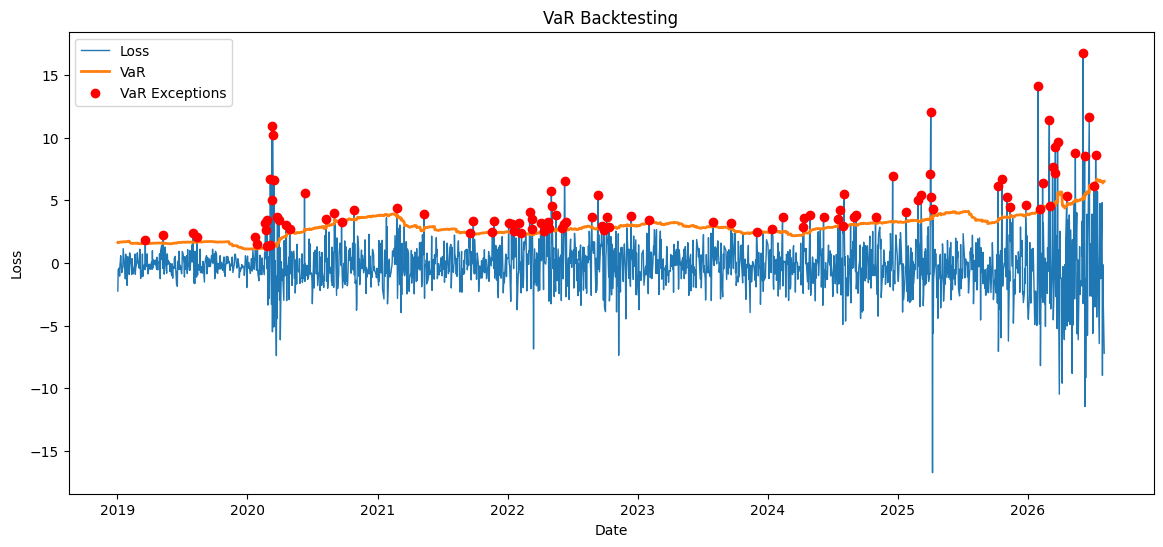

In [17]:
plt.figure(figsize=(14,6))

plt.plot(
    backtest.index,
    backtest["Loss"],
    label="Loss",
    linewidth=1
)

plt.plot(
    backtest.index,
    backtest["VaR"],
    label="VaR",
    linewidth=2
)

# Excepciones
exceptions = backtest[backtest["VaR Exception"]]

plt.scatter(
    exceptions.index,
    exceptions["Loss"],
    color="red",
    label="VaR Exceptions",
    zorder=3
)

plt.title("VaR Backtesting")
plt.xlabel("Date")
plt.ylabel("Loss")
plt.legend()

plt.show()

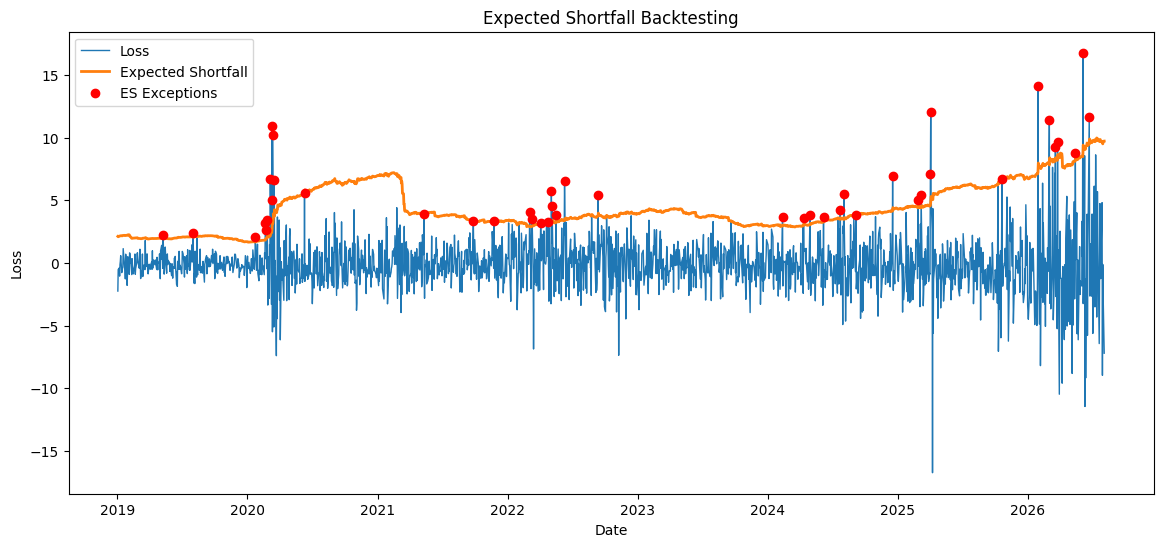

In [18]:
plt.figure(figsize=(14,6))

plt.plot(
    backtest.index,
    backtest["Loss"],
    label="Loss",
    linewidth=1
)

plt.plot(
    backtest.index,
    backtest["ES"],
    label="Expected Shortfall",
    linewidth=2
)

exceptions = backtest[backtest["ES Exception"]]

plt.scatter(
    exceptions.index,
    exceptions["Loss"],
    color="red",
    label="ES Exceptions",
    zorder=3
)

plt.title("Expected Shortfall Backtesting")
plt.xlabel("Date")
plt.ylabel("Loss")
plt.legend()

plt.show()

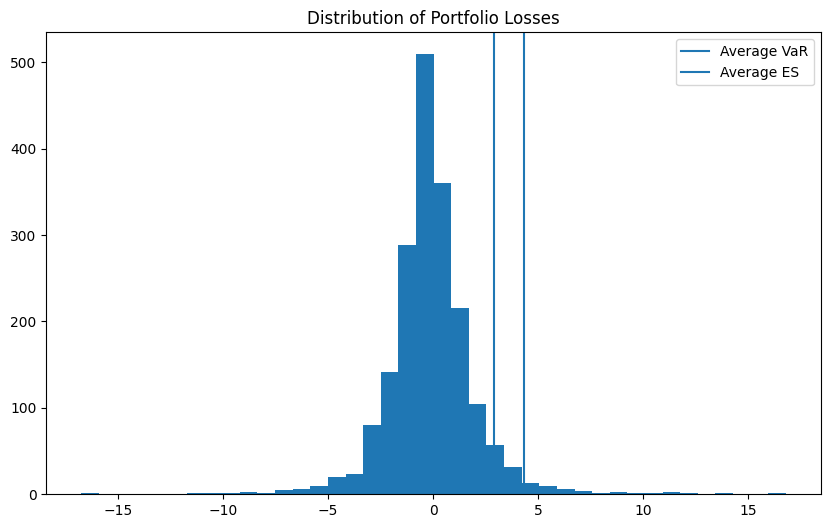

In [19]:
plt.figure(figsize=(10,6))

plt.hist(
    backtest["Loss"],
    bins=40
)

plt.axvline(
    backtest["VaR"].mean(),
    label="Average VaR"
)

plt.axvline(
    backtest["ES"].mean(),
    label="Average ES"
)

plt.legend()

plt.title("Distribution of Portfolio Losses")

plt.show()

The backtesting results allow visual inspection of periods where realized losses exceeded the estimated risk measures. A well-calibrated VaR model should produce an exception rate close to the theoretical tail probability used during estimation.

## Kupiec Test

Visual inspection alone is not sufficient to evaluate the calibration of a Value-at-Risk model. The Kupiec Proportion of Failures Test provides a formal statistical procedure for determining whether the observed number of VaR exceptions is consistent with the expected confidence level.

Under the null hypothesis, the observed exception frequency equals the theoretical tail probability used in the VaR estimation. A large p-value indicates that the model is adequately calibrated, whereas a small p-value suggests that the model either underestimates or overestimates portfolio risk.|

In [20]:
from scipy.stats import chi2

def kupiec_test(backtest, alpha=0.05):
    """
    Kupiec Proportion of Failures Test.

    Parameters
    ----------
    backtest : DataFrame
        Output of rolling_backtest().
    alpha : float
        Tail probability.

    Returns
    -------
    DataFrame
        Kupiec test results.
    """

    N = len(backtest)

    x = backtest["VaR Exception"].sum()

    p_hat = x / N

    LR = -2 * np.log(
        ((1-alpha)**(N-x) * alpha**x)
        /
        ((1-p_hat)**(N-x) * p_hat**x)
    )

    p_value = 1 - chi2.cdf(LR, df=1)

    LR = float(LR)
    p_value = float(p_value)

    return {
      "Statistic": LR,
      "p-value": p_value,
      "Exceptions": x,
      "Expected": N * alpha,
      "Decision": "Fail to Reject H₀" if p_value >= 0.05 else "Reject H₀"
    }

In [21]:
backtest_hist = rolling_backtest(
    prices,
    returns,
    weights,
    method="historical"
)

backtest_param = rolling_backtest(
    prices,
    returns,
    weights,
    method="parametric"
)

backtest_mc = rolling_backtest(
    prices,
    returns,
    weights,
    method="monte_carlo"
)

kupiec_results = pd.DataFrame([
    {
        "Method": "Historical",
        **kupiec_test(backtest_hist)
    },
    {
        "Method": "Parametric",
        **kupiec_test(backtest_param)
    },
    {
        "Method": "Monte Carlo",
        **kupiec_test(backtest_mc)
    }
])



In [22]:
kupiec_results

,Method,Statistic,p-value,Exceptions,Expected,Decision
0,Historical,1.018243,0.312936,105,95.25,Fail to Reject H₀
1,Parametric,0.492639,0.482753,102,95.25,Fail to Reject H₀
2,Monte Carlo,0.647374,0.421053,103,95.25,Fail to Reject H₀


The Kupiec Test complements the graphical backtesting analysis by providing statistical evidence regarding the adequacy of each VaR methodology. Comparing the p-values across the Historical, Parametric, and Monte Carlo approaches helps identify which model better captures the observed portfolio risk during the evaluation period.

## Conclusions

This project implemented and compared three widely used methodologies for portfolio risk estimation: Historical Simulation, the Parametric (Variance-Covariance) approach, and Monte Carlo Simulation. The results demonstrated how different modeling assumptions can influence Value-at-Risk and Expected Shortfall estimates while providing a complete workflow for portfolio risk analysis.

Rolling-window backtesting and the Kupiec Proportion of Failures Test were used to evaluate the calibration of the VaR models, highlighting the importance of validating risk estimates rather than relying solely on their numerical values.

Overall, this notebook illustrates a practical end-to-end framework for portfolio risk estimation, model comparison, and statistical validation using Python.

## Limitations

This implementation assumes:

- Static portfolio weights.
- Multivariate normality for Monte Carlo simulation.
- No transaction costs.
- No volatility clustering.
- No rebalancing.

## Future Work

Several extensions could further improve the realism and flexibility of this framework:

### GARCH or EWMA Volatility Models

Replace the assumption of constant volatility with time-varying volatility models to better capture volatility clustering and rapidly changing market conditions.

### Student's t Innovations

Replace the multivariate normal assumption in the Monte Carlo simulation with a multivariate Student's *t* distribution to better capture the heavy tails commonly observed in financial returns.

### Stress Testing

Evaluate portfolio performance under predefined adverse market scenarios, complementing statistical risk measures with scenario-based analysis.